Section 1-Goal: Predict house rent prices using property features.

Section 2-Importing Libraries

In [296]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Section 3- oading the Data

In [297]:
df=pd.read_csv("urban_rental_price.csv")

Section 4 - EDA

Checking shape, columns and data types 

In [298]:
df.head()      # Top 5 rows

,listing_date,city,locality,locality_tier,property_type,bedrooms,area_sqft,age_of_property,furnishing_status,floor_category,parking,tenant_preference,amenity_score,rent_price
0,16-09-2019,Bangalore,Whitefield,Mid-Range,Independent House,4,2058.1,3.6,Semi-Furnished,Mid (4-7),2-Wheeler Only,Any,9,82800
1,04-02-2020,Mumbai,Thane,Budget,Apartment,1,846.0,3.1,Semi-Furnished,Mid (4-7),No Parking,Company Lease,4,25400
2,07-09-2023,Bangalore,Indiranagar,Budget,Studio,1,250.0,22.2,Fully Furnished,Low (1-3),No Parking,Bachelor,6,12800
3,29-04-2023,Bangalore,Whitefield,Budget,Apartment,4,1604.5,13.3,Unfurnished,Mid (4-7),4-Wheeler Only,Company Lease,7,28700
4,31-07-2022,Bangalore,HSR Layout,Mid-Range,Apartment,2,574.5,12.1,Semi-Furnished,High (8-15),No Parking,Company Lease,1,32600


In [299]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   listing_date       250000 non-null  str    
 1   city               250000 non-null  str    
 2   locality           250000 non-null  str    
 3   locality_tier      250000 non-null  str    
 4   property_type      250000 non-null  str    
 5   bedrooms           250000 non-null  int64  
 6   area_sqft          250000 non-null  float64
 7   age_of_property    245000 non-null  float64
 8   furnishing_status  242500 non-null  str    
 9   floor_category     250000 non-null  str    
 10  parking            246250 non-null  str    
 11  tenant_preference  250000 non-null  str    
 12  amenity_score      250000 non-null  int64  
 13  rent_price         250000 non-null  int64  
dtypes: float64(2), int64(3), str(9)
memory usage: 26.7 MB


Checking Null Values

In [300]:
df.isnull().sum()       # 3 columns have Null Values

listing_date            0
city                    0
locality                0
locality_tier           0
property_type           0
bedrooms                0
area_sqft               0
age_of_property      5000
furnishing_status    7500
floor_category          0
parking              3750
tenant_preference       0
amenity_score           0
rent_price              0
dtype: int64

In [301]:
# We have to Replace Null values for integer type columns with Mean or Median values
# And for the column With data type as string null values will be replaced by Mode of that column

Checking Outliers in Age of property Column

<Axes: >

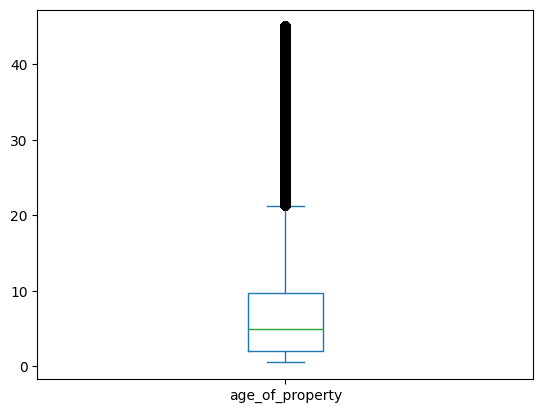

In [302]:
df["age_of_property"].plot(kind="box")   # box plot to identify Outliers

Section 5 - Data Cleaning

Since age of property has Outliers We will Use median() to replace Null Values

In [303]:
# Replacing Null Values with Median()
df["age_of_property"]=df["age_of_property"].fillna(df["age_of_property"].median(),inplace=True)

Now Replacing Null values for Categorical Columns with mode()

In [304]:
# Replacing Null values for Furnishing Status Column
df["furnishing_status"]=df["furnishing_status"].mode()[0]

In [305]:
# Replacing Null values for Parking Column
df["parking"]=df["parking"].mode()[0]

In [306]:
# All Null values Replaced Successfully
df.isnull().sum()

listing_date         0
city                 0
locality             0
locality_tier        0
property_type        0
bedrooms             0
area_sqft            0
age_of_property      0
furnishing_status    0
floor_category       0
parking              0
tenant_preference    0
amenity_score        0
rent_price           0
dtype: int64

Now Checking outliers or Extreme Values in Columns bedrooms,area_sqft,age_of_property,amenity_score and Rent Price

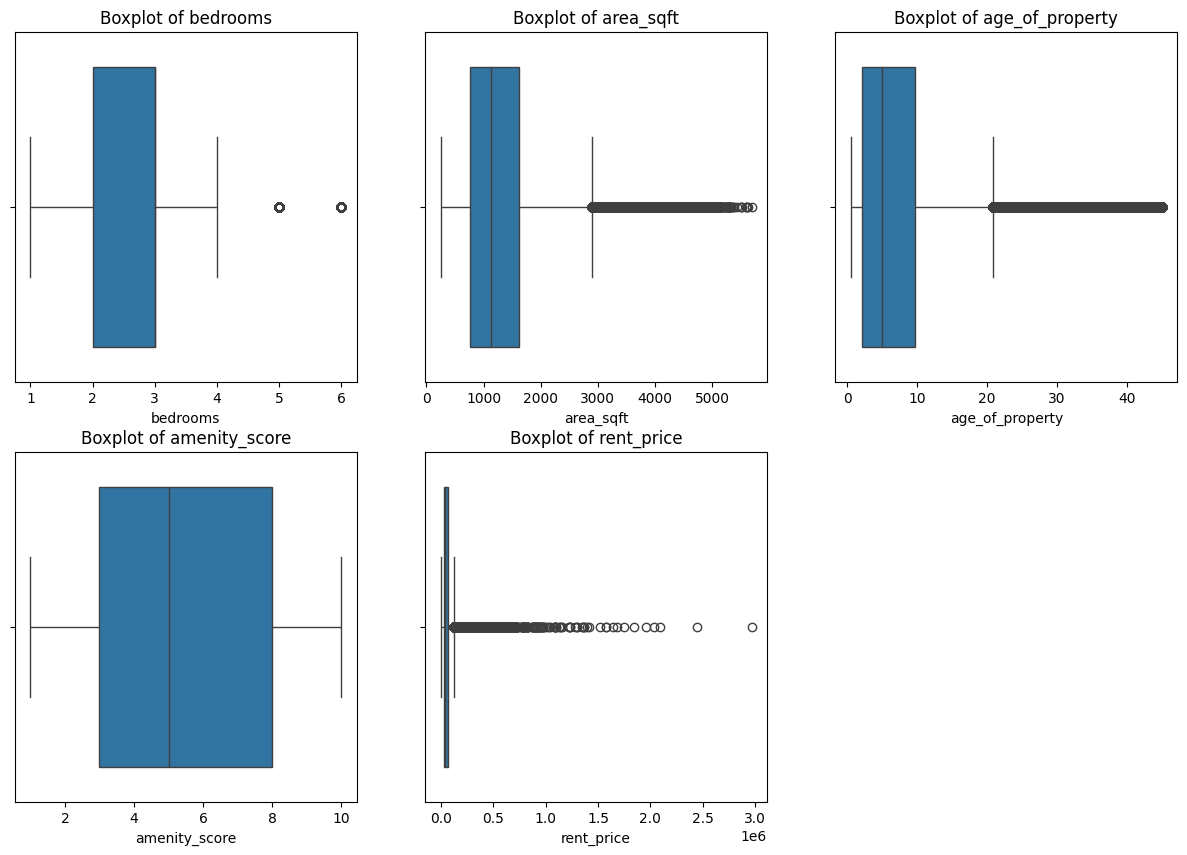

In [ ]:
# Create figure and subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Flatten axes for easier indexing
axes = axes.flatten()

# List of columns
columns = ["bedrooms","area_sqft","age_of_property","amenity_score","rent_price"]

# Create boxplots
for i, col in enumerate(columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

# Remove extra empty subplot
fig.delaxes(axes[5])

# Show plots
plt.show()

As We can see from Above Plots that columns(area-sqft,age_of_property,rent_price) have Ouliers So we will be Mild Clipping the Columns

In [308]:
# Mild clipping using 99th percentile because values are Realistic

upper_limit_area = df["area_sqft"].quantile(0.99)

df["area_sqft"] = df["area_sqft"].clip(
    upper=upper_limit_area
)

In [309]:
# Mild clipping using 99th percentile because Values are Realistic

upper_limit_age = df["age_of_property"].quantile(0.99)

df["age_of_property"] = df["age_of_property"].clip(
    upper=upper_limit_age
)

In [310]:
# LOG TRANSFORMATION OF TARGET VARIABLE
import numpy as np

df["rent_price_log"] = np.log(df["rent_price"])

Checking Results After Clipping

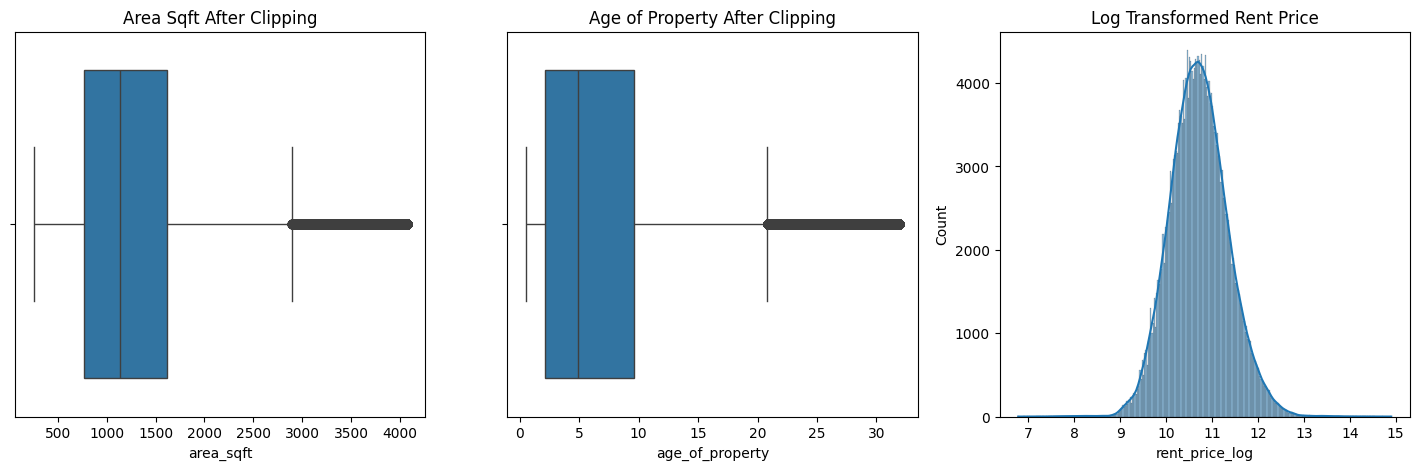

In [311]:
# Create subplot layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Boxplot: area_sqft
sns.boxplot(x=df["area_sqft"], ax=axes[0])
axes[0].set_title("Area Sqft After Clipping")

# Boxplot: age_of_property
sns.boxplot(x=df["age_of_property"], ax=axes[1])
axes[1].set_title("Age of Property After Clipping")

# Histogram: rent_price_log
sns.histplot(
    df["rent_price_log"],
    kde=True,
    ax=axes[2]
)
axes[2].set_title("Log Transformed Rent Price")

# Show plots
plt.show()

In above Plots we kept some Outliers because they were Realistic and Only Clipped Extreme Values

In [312]:
# Changing Date column in Date Data Type
df["listing_date"]=pd.to_datetime(df["listing_date"])

Section 6 -Feature Engineering

Dropping Column Parking and Furnishing Status because of no Variation in the Data

In [313]:
# Dropping Parking Column
df["parking"].unique()                           # Only 1 Unique Value is Available
df=df.drop(columns="parking")

# Dropping Furnishing Status Column
df["furnishing_status"].unique()                 # Only 1 Unique Value is Available
df=df.drop(columns="furnishing_status")

Now we will Encode Date type and Categorical Type Columns

In [314]:
# Categorical Columns
# Nominal - city,locality,property_type,tenant_preference
# Ordinal - locality_tier,floor_category
# Date columns
# listing_date

Encoding Date Column

In [315]:
df["year"] = df["listing_date"].dt.year
df["month"] = df["listing_date"].dt.month
df["day"] = df["listing_date"].dt.day

# Dropping Original Date column after Encoding
df=df.drop(columns="listing_date")

Encoding for Nominal Columns

In [ ]:
df = pd.get_dummies(
    df,
    columns=["city","locality","property_type","tenant_preference"],
    drop_first=True,dtype=np.int64
)

Ordinal Encoding

In [317]:
# Encoding for Column floor_category
df["floor_category"] = df["floor_category"].map({
    "Ground": 0,
    "Low (1-3)": 1,
    "Mid (4-7)": 2,
    "High (8-15)": 3,
    "Penthouse (16+)": 4
})

In [318]:
# Encoding for Column locality_tier 
df["locality_tier"] = df["locality_tier"].map({
    "Budget": 1,
    "Mid-Range": 2,
    "Premium": 3
})

In [319]:
df.head()

,locality_tier,bedrooms,area_sqft,age_of_property,floor_category,amenity_score,rent_price,rent_price_log,year,month,...,locality_Wakad,locality_Whitefield,locality_Yelahanka,property_type_Builder Floor,property_type_Independent House,property_type_Studio,property_type_Villa,tenant_preference_Bachelor,tenant_preference_Company Lease,tenant_preference_Family
0,2,4,2058.1,3.6,2,9,82800,11.324183,2019,9,...,0,1,0,0,1,0,0,0,0,0
1,1,1,846.0,3.1,2,4,25400,10.142504,2020,2,...,0,0,0,0,0,0,0,0,1,0
2,1,1,250.0,22.2,1,6,12800,9.457200,2023,9,...,0,0,0,0,0,1,0,1,0,0
3,1,4,1604.5,13.3,2,7,28700,10.264652,2023,4,...,0,1,0,0,0,0,0,0,1,0
4,2,2,574.5,12.1,3,1,32600,10.392068,2022,7,...,0,0,0,0,0,0,0,0,1,0


Section 7 - Train Test Split

In [320]:
X=df.drop(columns=["rent_price","rent_price_log"])  

In [321]:
y=df["rent_price_log"]

Splitting Data into 80 and 20%

In [322]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

Feature Scaling Columns

In [ ]:
# Columns Need to be Scaled
num_cols = ["area_sqft","bedrooms","age_of_property","amenity_score"]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols])
X_test[num_cols] = scaler.transform(
    X_test[num_cols])

Saving the Data as CSV File for reproducability

In [327]:
X_train.to_csv("X_train.csv", index=False)

X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)

y_test.to_csv("y_test.csv", index=False)

Section 8 - Model Building

In [ ]:
# Importing Metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [329]:
# Training Model
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [331]:
# Predicting on Test data
y_predlog=model.predict(X_test)

In [332]:
# Convert predictions back to original rent scale
y_pred_actual = np.exp(y_predlog)

# Convert actual y_test back to original scale
y_test_actual = np.exp(y_test)

Section 9 - Evaluating metrics

In [333]:
#Claculating Metrics
rmse=np.sqrt(mean_squared_error(y_test_actual,y_pred_actual))

mae=mean_absolute_error(y_test_actual,y_pred_actual)

r2=r2_score(y_test_actual,y_pred_actual)


In [338]:
print("RMSE :", rmse)

print("MAE :", mae)

print("R² Score :", r2)


RMSE : 25572.210568682283
MAE : 6967.814557895266
R² Score : 0.6930312525235032


In [340]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_})

# Absolute importance

coefficients["Abs_Coefficient"] = (
    coefficients["Coefficient"].abs())

# Sort descending
top_features = coefficients.sort_values(
    by="Abs_Coefficient",
    ascending=False).head(10)

print(top_features)

                            Feature  Coefficient  Abs_Coefficient
58              property_type_Villa     0.575599         0.575599
0                     locality_tier     0.401099         0.401099
57             property_type_Studio    -0.385982         0.385982
13                        city_Pune    -0.339537         0.339537
12                      city_Mumbai     0.312150         0.312150
56  property_type_Independent House     0.297415         0.297415
9                      city_Chennai    -0.287008         0.287008
11                   city_Hyderabad    -0.163437         0.163437
55      property_type_Builder Floor     0.145551         0.145551
1                          bedrooms     0.137845         0.137845


Residuals Vs Fitted Values

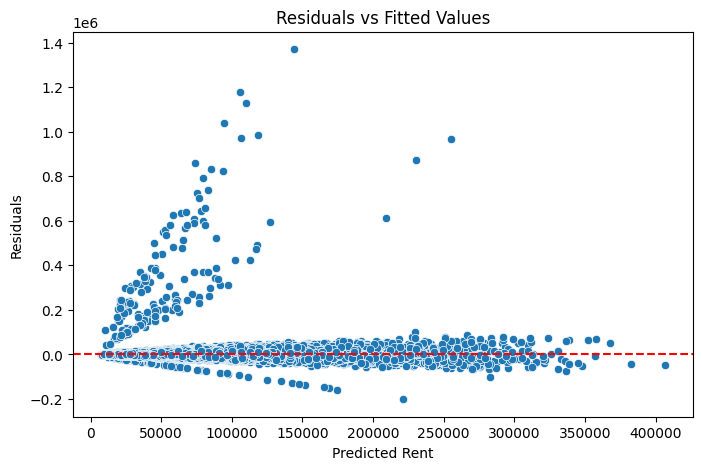

In [ ]:
residuals = y_test_actual - y_pred_actual
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_actual,y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Rent")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

Q-Q Plot of Residuals

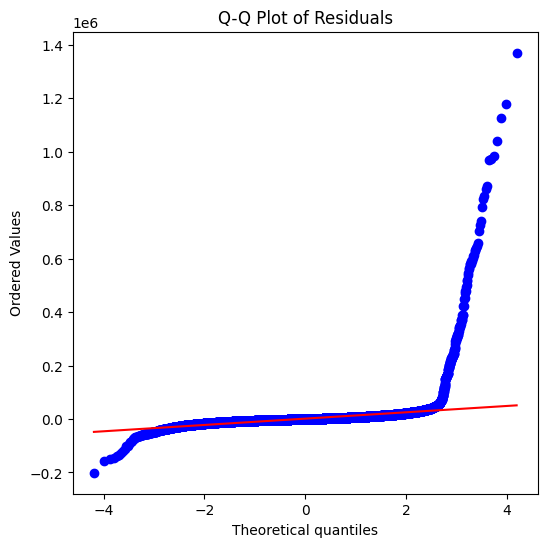

In [ ]:
import scipy.stats as stats
plt.figure(figsize=(6,6))
stats.probplot(residuals,dist="norm",plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

Actual vs Predicted Scatter Plot

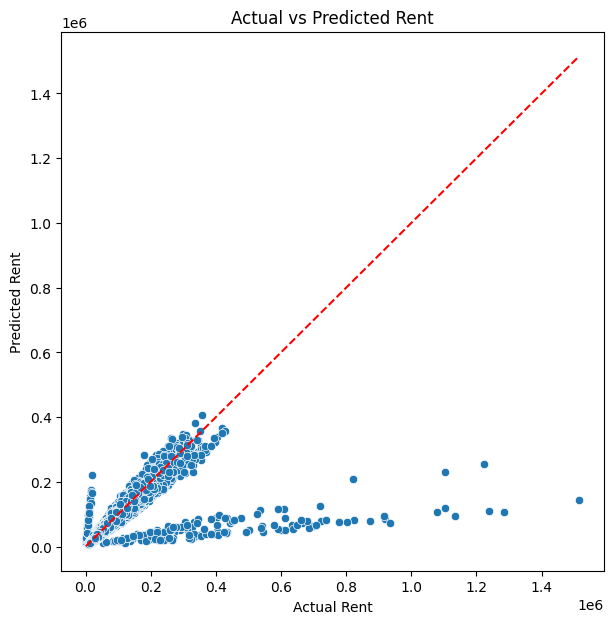

In [343]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test_actual,y=y_pred_actual)

# 45-degree line
plt.plot([y_test_actual.min(), y_test_actual.max()],[y_test_actual.min(), y_test_actual.max()],
    color="red",
    linestyle="--")
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent")
plt.show()

Percentage Error Distribution

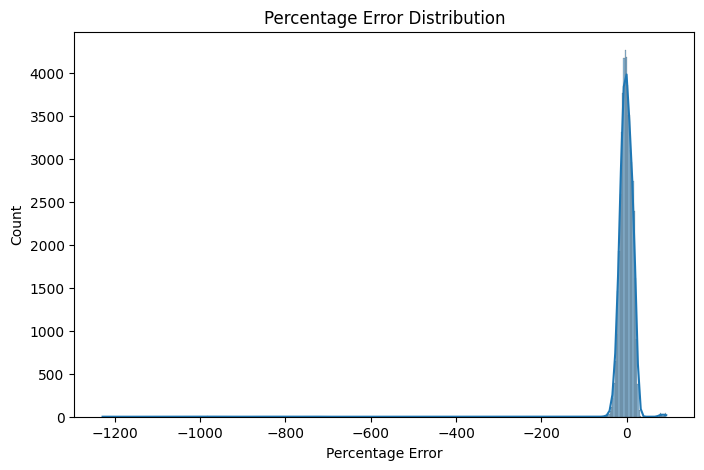

In [344]:
percentage_error = ((y_test_actual - y_pred_actual)/ y_test_actual) * 100
plt.figure(figsize=(8,5))
sns.histplot(percentage_error,kde=True)
plt.title("Percentage Error Distribution")
plt.xlabel("Percentage Error")
plt.show()

Section 10 - The model achieved an R² score of 0.69 and successfully captured key rental pricing patterns.